**Table of contents**<a id='toc0_'></a>    
- [Modeling of PFAs](#toc1_)    
  - [Reading data and fitting parameters](#toc1_1_)    
    - [4 Fluorophores](#toc1_1_1_)    
  - [r2 score and residuals](#toc1_2_)    
  - [Figure](#toc1_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Modeling of PFAs](#toc0_)

In [136]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import rcParams
from sklearn.metrics import r2_score

import fluopy.figure as fi
import fluopy.distributions as dist
import fluopy.routines as rt

%load_ext autoreload
%autoreload 2

reading_from = r"D:\python_output\Chapter_I\0_5_modeling"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_1_'></a>[Reading data and fitting parameters](#toc0_)

### <a id='toc1_1_1_'></a>[4 Fluorophores](#toc0_)

In [137]:
distances = [3, 5, 6, 8]
identifiers = [f"{distance}nm" for distance in distances]
delta_bleaching_times_4f_all = []
bleaching_times_4f_all = []
fingerprints_4f_all = []
emission_data = []
for i, id in enumerate(identifiers):
    for file in glob.glob(reading_from + f"/4F/*"):
        if file.endswith(".npy") and id in file:
            bleaching_times_4f = np.load(file)
            bleaching_times_4f_all.append(bleaching_times_4f)
            delta_bleaching_times_4f_all.append(
                rt.get_global_bleaching_rates(bleaching_times_4f)[1]
            )
        if file.endswith(".parquet") and id in file:
            fingerprint = pd.read_parquet(file).sum(axis=1)
            emission_data.append(fingerprint)
            fingerprint = fingerprint.cumsum() / fingerprint.sum()
            fingerprints_4f_all.append(fingerprint)
fits = ["1f", "2f", "3f", "4f"]
parameters_4f_all = []
for fit in fits:
    for file in glob.glob(reading_from + f"/4F/4_fluo_k_fluo_fingerprint_fits/*"):
        if file.endswith(f"{fit}.npy"):
            parameters_4f_all.append(np.load(file))

photon_arrival_times = np.repeat(
    emission_data[0].index.values, emission_data[0].values.astype(int)
)

c:\Users\vie43sq\uv_envs\phd_main\Lib\site-packages\scipy\optimize\_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
c:\Users\vie43sq\uv_envs\phd_main\Lib\site-packages\scipy\optimize\_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
c:\Users\vie43sq\uv_envs\phd_main\Lib\site-packages\scipy\optimize\_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
c:\Users\vie43sq\uv_envs\phd_main\Lib\site-packages\scipy\optimize\_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


## <a id='toc1_2_'></a>[r2 score and residuals](#toc0_)

In [138]:
r_2_scores = []
residuals_all = []
for fingerprint, param1f, param2f, param3f, param4f in zip(
    fingerprints_4f_all,
    parameters_4f_all[0],
    parameters_4f_all[1],
    parameters_4f_all[2],
    parameters_4f_all[3],
):
    y = fingerprint.values
    x = np.linspace(0, 300, 300001)
    r2_score_1f = r2_score(
        y, dist.ps_fingerprint_cdf_1f(x, *param1f, domain=(x[0], x[-1]))
    )
    r2_score_2f = r2_score(
        y, dist.ps_fingerprint_cdf_2f(x, *param2f, domain=(x[0], x[-1]))
    )
    r2_score_3f = r2_score(
        y, dist.ps_fingerprint_cdf_3f(x, *param3f, domain=(x[0], x[-1]))
    )
    r2_score_4f = r2_score(
        y, dist.ps_fingerprint_cdf_4f(x, *param4f, domain=(x[0], x[-1]))
    )
    r_2_scores.append([r2_score_1f, r2_score_2f, r2_score_3f, r2_score_4f])
    residual_1f = y - dist.ps_fingerprint_cdf_1f(x, *param1f, domain=(x[0], x[-1]))
    residual_2f = y - dist.ps_fingerprint_cdf_2f(x, *param2f, domain=(x[0], x[-1]))
    residual_3f = y - dist.ps_fingerprint_cdf_3f(x, *param3f, domain=(x[0], x[-1]))
    residual_4f = y - dist.ps_fingerprint_cdf_4f(x, *param4f, domain=(x[0], x[-1]))
    residuals = [residual_1f, residual_2f, residual_3f, residual_4f]
    residuals_all.append(residuals)

## <a id='toc1_3_'></a>[Figure](#toc0_)

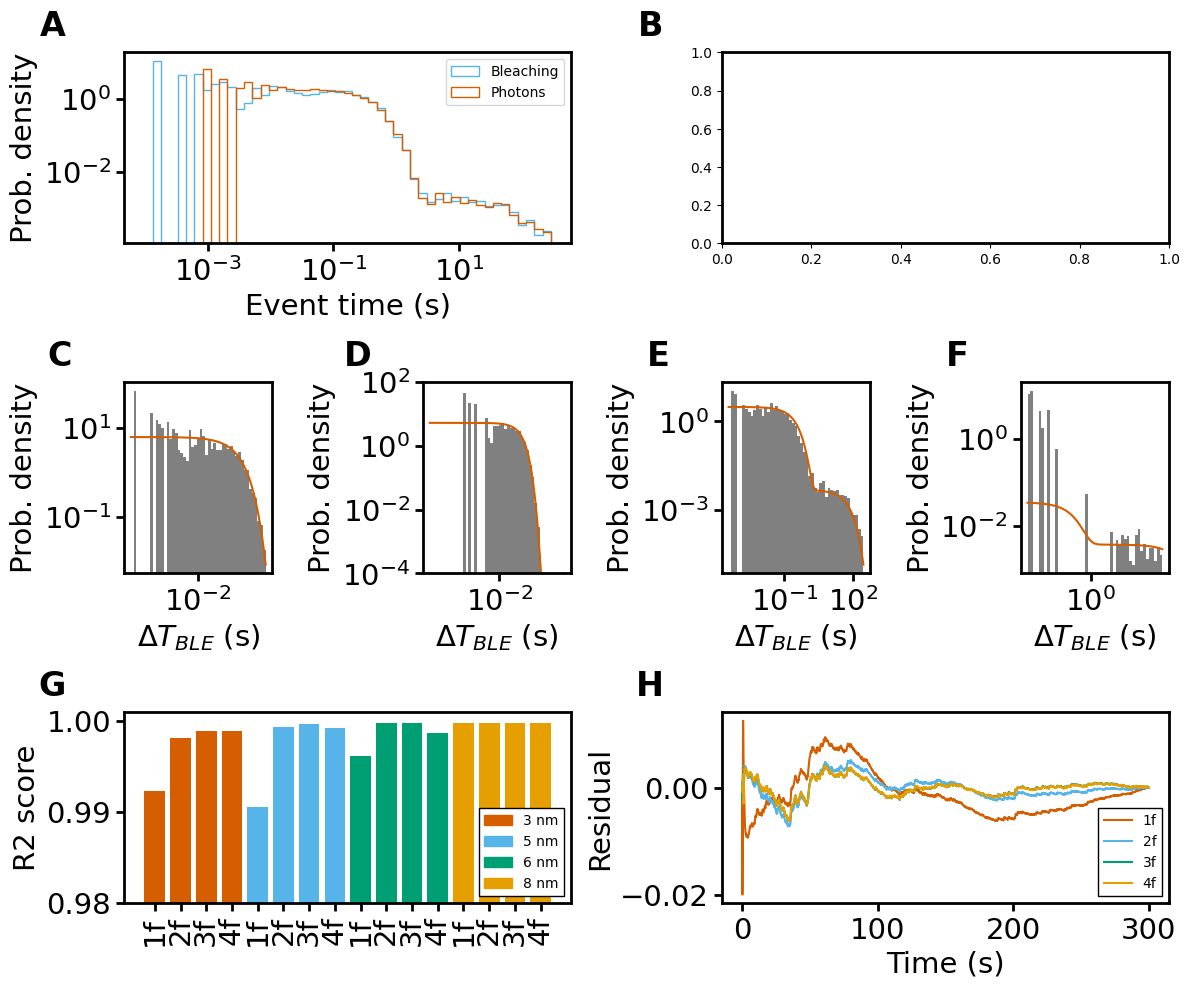

In [139]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 4)
fig = plt.figure(figsize=(12, 10))

ax1 = fig.add_subplot(gs[0, :2])
data = bleaching_times_4f_all[0].flatten()
data = data[~np.isnan(data)]
bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 50)
fi.universal_figure(
    type_="hist",
    data=data,
    bins=bins,
    axes=ax1,
    label="Bleaching",
    density=True,
    histtype="step",
    color=sky_blue,
)
fi.universal_figure(
    type_="hist",
    data=photon_arrival_times,
    xscale="log",
    yscale="log",
    bins=bins,
    axes=ax1,
    density=True,
    color=red,
    histtype="step",
    label="Photons",
    ylabel="Prob. density",
    xlabel=r"Event time (s)",
    legend=True,
)
ax2 = fig.add_subplot(gs[0, 2:])
ax3 = fig.add_subplot(gs[1, 0])
data = delta_bleaching_times_4f_all[0][0]
bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 50)
x = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 1000)
lambda1, lambda2, pi = parameters_4f_all[3][0][0::4]
fi.universal_figure(
    axes=ax3,
    data=data,
    bins=bins,
    type_="hist",
    density=True,
    xscale="log",
    yscale="log",
    color="grey",
)
fi.universal_figure(
    type_="line",
    data=[x, dist.two_expon_mixture_pdf(x, lambda1, lambda2, pi)],
    axes=ax3,
    yscale="log",
    xscale="log",
    xlabel=r"$\Delta T_{BLE}$ (s)",
    ylabel="Prob. density",
    color=red,
)
ax4 = fig.add_subplot(gs[1, 1])
data = delta_bleaching_times_4f_all[0][1]
bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 50)
x = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 1000)
lambda1, lambda2, pi = parameters_4f_all[3][0][1::4]
fi.universal_figure(
    axes=ax4,
    data=data,
    bins=bins,
    type_="hist",
    density=True,
    xscale="log",
    yscale="log",
    color="grey",
)
fi.universal_figure(
    type_="line",
    data=[x, dist.two_expon_mixture_pdf(x, lambda1, lambda2, pi)],
    axes=ax4,
    yscale="log",
    xscale="log",
    xlabel=r"$\Delta T_{BLE}$ (s)",
    ylabel="Prob. density",
    color=red,
    ylim=[1e-4, 1e2],
)
ax5 = fig.add_subplot(gs[1, 2])
data = delta_bleaching_times_4f_all[0][2]
bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 50)
x = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 1000)
lambda1, lambda2, pi = parameters_4f_all[3][0][2::4]
fi.universal_figure(
    axes=ax5,
    data=data,
    bins=bins,
    type_="hist",
    density=True,
    xscale="log",
    yscale="log",
    color="grey",
)
fi.universal_figure(
    type_="line",
    data=[x, dist.two_expon_mixture_pdf(x, lambda1, lambda2, pi)],
    axes=ax5,
    yscale="log",
    xscale="log",
    xlabel=r"$\Delta T_{BLE}$ (s)",
    ylabel="Prob. density",
    color=red,
)
ax6 = fig.add_subplot(gs[1, 3])
data = delta_bleaching_times_4f_all[0][3]
bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 50)
x = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 1000)
lambda1, lambda2, pi = parameters_4f_all[3][0][3::4]
fi.universal_figure(
    axes=ax6,
    data=data,
    bins=bins,
    type_="hist",
    density=True,
    xscale="log",
    yscale="log",
    color="grey",
)
fi.universal_figure(
    type_="line",
    data=[x, dist.two_expon_mixture_pdf(x, lambda1, lambda2, pi)],
    axes=ax6,
    yscale="log",
    xscale="log",
    xlabel=r"$\Delta T_{BLE}$ (s)",
    ylabel="Prob. density",
    color=red,
)
ax7 = fig.add_subplot(gs[2, :2])
r2 = np.array(r_2_scores).flatten()
colors = [red] * 4 + [sky_blue] * 4 + [green] * 4 + [orange] * 4
labels = ["1f", "2f", "3f", "4f"] * 4
patches = [
    Patch(color=red, label="3 nm"),
    Patch(color=sky_blue, label="5 nm"),
    Patch(color=green, label="6 nm"),
    Patch(color=orange, label="8 nm"),
]
fi.universal_figure(
    type_="bar",
    data=[np.arange(0, 16, 1), r2],
    axes=ax7,
    ylim=[0.98, 1.001],
    ylabel="R2 score",
    xlabel="",
    legendhandles=patches,
    legend=True,
    legendargs=dict(framealpha=1, edgecolor="black", fancybox=False, loc="lower right"),
    color=colors,
    xticks=np.arange(0, 16, 1),
    xticklabels=dict(labels=labels, rotation=90),
)
ax8 = fig.add_subplot(gs[2, 2:])
x = np.linspace(0, 300, 300001)
labels = ["1f", "2f", "3f", "4f"] * 4
colors = [red, sky_blue, green, orange]
for i, residual in enumerate(residuals_all[0]):
    fi.universal_figure(
        axes=ax8,
        type_="line",
        data=[x, residual],
        color=colors[i],
        label=labels[i],
        legend=True,
        ylabel="Residual",
        xlabel="Time (s)",
        legendargs=dict(
            framealpha=1,
            edgecolor="black",
            fancybox=False,
        ),
    )


axes = fig.get_axes()
for i, (axis, letter) in enumerate(zip(axes, ["A", "B", "C", "D", "E", "F", "G", "H"])):
    offset = -0.13
    if i > 1 and i < 6:
        offset = -0.35
    axis.text(
        offset,
        1.05,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
fig.tight_layout()
fig.savefig(
    reading_from + r"\modeling.png", bbox_inches="tight", pad_inches=0.1, dpi=300
)